#__KNN Classification Using the Iris Dataset__

In [1]:
pip install pandas scikit-learn matplotlib seaborn


In [2]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

In [4]:
# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



In [5]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [6]:
# Try different values of K
accuracies = []
k_range = range(1, 21)
for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

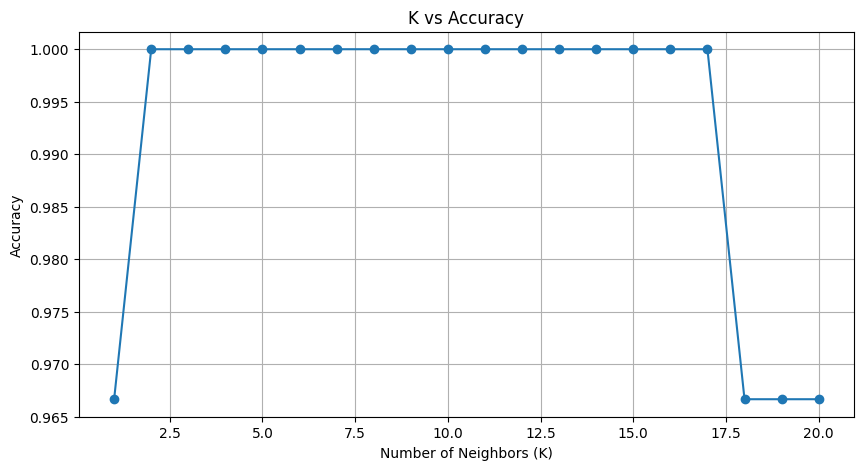

In [7]:
# Plot accuracy vs. K
plt.figure(figsize=(10, 5))
plt.plot(k_range, accuracies, marker='o')
plt.title("K vs Accuracy")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

In [8]:
# Final model with best K
best_k = k_range[np.argmax(accuracies)]
print(f"Best K: {best_k}")


Best K: 2


In [9]:
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [10]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=target_names))

Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



#__Visualization of Decision Boundaries__

In [11]:
from matplotlib.colors import ListedColormap

In [12]:
# Use only 2 features for plotting (e.g., petal length & petal width)
X_plot = X_scaled[:, [2, 3]]


In [13]:
X_train_plot, X_test_plot, y_train, y_test = train_test_split(X_plot, y, test_size=0.2, random_state=42)
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train_plot, y_train)


KNeighborsClassifier(n_neighbors=2)

In [14]:
# Create meshgrid
x_min, x_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
y_min, y_max = X_plot[:, 1].min() - 1, X_plot[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))


In [15]:
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


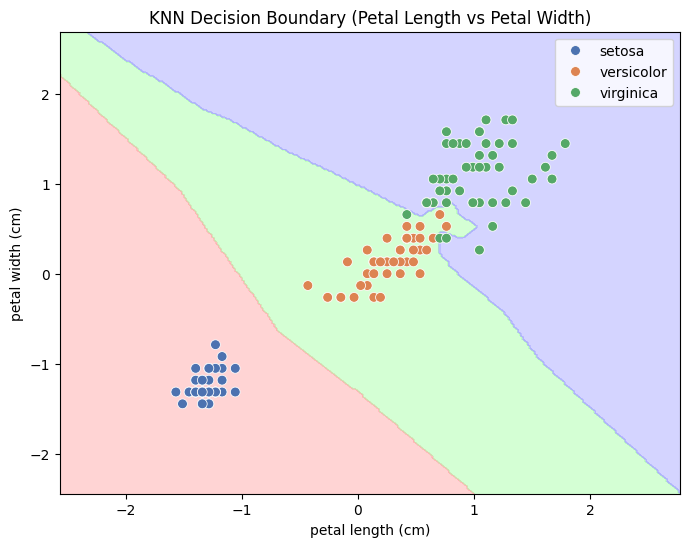

In [16]:
# Plot decision boundaries
plt.figure(figsize=(8, 6))
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.5)
sns.scatterplot(x=X_plot[:, 0], y=X_plot[:, 1], hue=iris.target_names[y], palette="deep", s=50)
plt.xlabel(feature_names[2])
plt.ylabel(feature_names[3])
plt.title("KNN Decision Boundary (Petal Length vs Petal Width)")
plt.show()